# L6d: Let's use a Modern Hopfield Network as a Synthetic Data Generator
Fill me in later. 

> __Learning Objectives:__
> 
> By the end of this lab, you will be able to:
>  Three learning objectives here.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Environment Setup with Include.jl__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
We gathered a daily open-high-low-close `dataset` for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for a few exchange-traded funds and volatility products during that time. 

Let's load the `original_dataset::DataFrame` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x -> x["dataset"]; # load the original dataset

Not all tickers in our dataset have the maximum number of trading days for various reasons, e.g., acquisition or de-listing events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has a maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # nrow? (check out: DataFrames.jl)

2767

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # what is this doing?
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

How many firms do we have the full number of trading days? Let's use [the `length(...)` method](https://docs.julialang.org/en/v1/base/collections/#Base.length) - notice this works for dictionaries, in addition to arrays, sets and other collections.

In [5]:
length(dataset) # tells us how many keys are in the dictionary (how many firms in our dataset?)

424

Finally, let's get a list of the firms in our cleaned up dataset (and sort them alphabetically). We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable.

In [6]:
list_of_tickers = keys(dataset) |> collect |> sort # list of firm "ticker" symbols in alphabetical order

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 ⋮
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

### Constants
Before we get to the main part of the lab, let's set some constants that we will use later on. We will use these constants to control the number of memories we load, and the number of synthetic data points we generate, etc. See the comment next to each constant for more information about what it is, its permissible values, units, etc. 

In [7]:
β = 100.0; # inverse temperature (high β means low temperature, which means more deterministic behavior; low β means high temperature, which means more stochastic behavior)

___

## Task 1: Compute the growth rate matrix
In this task, we compute the growth rate array which contains, for each day and each firm in our dataset, the value of the growth rate between time $j$ and $j-1$. 

>  __Continuously Compounded Growth Rate (CCGR)__
>
> The share price of firm $i$ is governed by an expression of the form:
>$$
\begin{align*}
S^{(i)}_{j} &= S^{(i)}_{j-1}\;\exp\left(\underbrace{g^{(i)}_{j,j-1}\Delta{t}_{j}}_{\text{return}}\right)
\end{align*}
> $$
> where $S^{(i)}_{j-1}$ denotes the share price of firm $i$ at time index $j-1$, $S^{(i)}_{j}$ denotes the share price of firm $i$ at time index $j$, and $\Delta{t}_{j} = t_{j} - t_{j-1}$ denotes the length of a time step (units: years) between time index $j-1$ and $j$. The value we are going to estimate is the return, which is the growth rate $g^{(i)}_{j,j-1}$ (units: inverse years) for each firm $i$ multiplied by the time step in the dataset. 

We've implemented [the `log_growth_rate(...)` function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/data/#VLDataScienceMachineLearningPackage.log_growth_matrix) which takes the cleaned up dataset, and a list of ticker symbols, and returns the growth rate array. Each row of the growth rate array is a time step, while each column corresponds to a firm from the `list_of_tickers::Array{String,1}` array.

In [8]:
G = let

    # initialize -
    r̄ = 0.0; # assume the risk-free rate is 0
    Δt = (1/252); # time step size (units: years)

    # what are my input tickers?

    # compute the growth matrix -
    growth_rate_array = log_growth_matrix(dataset, list_of_tickers, Δt = Δt, 
        risk_free_rate = r̄); # other optional parameters are at their defaults
    
    growth_rate_array; # return
end;

__So what are our memories?__ In this application, the memory vectors that we will load are the daily growth rate vectors for all the firms in the dataset, i.e., each memory will be 1-day of trading data for all the firms in the dataset. Let's scale the data to have zero-mean, and unit length and save it in the `scaled_memories::Array{Float64,2}` variable. 

In [9]:
memories, scaled_memories = let

    # initialize -
    ϵ = 1e-12; # small number to avoid division by zero
    memories = transpose(G) |> Matrix; # each column is a memory vector (day in the market), and each row is a feature (a firm in the dataset)
    (number_of_rows, number_of_columns) = size(memories); # get the dimensions of the memories array

    # scale the memories to have zero-mean, and unit length
    scaled_memories = zeros(number_of_rows, number_of_columns);
    for i in 1:number_of_columns
        memory = memories[:,i]; # unscaled memory vector (day in the market)
        mean_memory = mean(memory); # what was the mean value for the growth rate that day (across all firms)?
        memory_centered = memory .- mean_memory; # center the memory vector by subtracting the mean value
        norm_memory_centered = norm(memory_centered) + ϵ; # compute the norm of the centered memory vector, and add a small number to avoid division by zero
        scaled_memories[:,i] = memory_centered ./ (norm_memory_centered + ϵ); # scale the memory vector to have unit length
    end
   
    # return -
    (memories, scaled_memories);
end;

__Check__: So if the scaling logic is correct, then the mean of each column of `scaled_memories::Array{Float64,2}` should be approximately zero, and the magnitude of each memory should be approximately 1. Let's check that is the case by computing the mean of each column, and the magnitude of each memory vector.

In [10]:
let

    # initialize -
    X = scaled_memories; # our input data (memories) for the Boltzmann machine
    number_of_memories = size(memories, 2); # how many memories do we have? (how many days of trading data do we have?)
    ϵ = 1e-10; # absolute tolerance for checking if the mean is approximately zero, and if the norm is approximately 1
    
    # Checks -
    for i ∈ 1:number_of_memories
        memory = X[:,i]; # get the i-th memory vector
        mean_memory = mean(memory); # compute the mean of the memory vector
        norm_memory = norm(memory); # compute the norm of the memory vector
        
        @assert isapprox(mean_memory, 0.0; atol = ϵ) "Mean of memory vector $i is not approximately zero: mean = $mean_memory"
        @assert isapprox(norm_memory, 1.0; atol = ϵ) "Norm of memory vector $i is not approximately 1: norm = $norm_memory"
    end
end

If we get here, and there were no errors then our scaling logic was correct, and we can now build our modern Hopfield network model.

### Encode a modern Hopfield model
Now that we have the training images, let's encode the model. We'll construct [a `MyModernHopfieldNetworkModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyModernHopfieldNetworkModel) using a custom [`build(...)` function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build). 

> __How do we build this model?__ We build the model using [the `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build). This method takes the type of thing we want to construct, namely [a `MyModernHopfieldNetworkModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyModernHopfieldNetworkModel), the (linearized) image library we want to encode, and the inverse temperature $\beta$ as inputs. The [`build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build) returns a model instance with the `X` (memory matrix) and `β` (inverse temperature) fields populated.

Let's store the encoded model in the `model::MyModernHopfieldNetworkModel` variable.

In [11]:
model = build(MyModernHopfieldNetworkModel, (
    memories = memories, # this is the data we want to memorize. Images on columns
    normalized_memories = scaled_memories, # normalized images on columns
    β = β, # Inverse temperature of the system. A big beta means we are more likely to get a definitive answer, small beta means more stochastic behavior
));

## Task 2: Let's run the Hopfield model in retrieval mode
In this task, we'll run the modern Hopfield network in retrieval mode, i.e., with $\beta\gg{1}$ (small temperature, which means more deterministic behavior). We'll give the model corrupted versions of market behavior on a given day, and see if the model can retrieve the original memory (the original market behavior for that day).

We'll start by picking a random day from our dataset, and then we'll corrupt the memory for that day by adding some noise to it. Finally, we'll give the corrupted memory to the model, and see if it can retrieve the original memory.

In [12]:
s₁,ŝ₁,i₁ = let 
    
    # select a random memory vector (day in the market) from the dataset
    number_of_memories = size(memories, 2); # how many memories do we have? (how many days of trading data do we have?)
    random_index = rand(1:number_of_memories); # select a random index
    original_memory = memories[:, random_index]; # get the original memory vector (the original market behavior for that day)
    σ = 0.5; # standard deviation of the noise to add to the memory vector

    # corrupt the memory vector by adding some noise to it
    noise = σ * randn(size(original_memory)); # generate some random noise
    corrupted_memory = original_memory + noise; # add the noise to the original memory vector to get the corrupted memory vector

    # return -
    (original_memory, corrupted_memory, random_index);
end;

Now that we have a corrupted initial memory $\hat{\mathbf{s}}_{1}$, can the network recover the original memory? Let's call [the `recover(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.recover-Union{Tuple{T},%20Tuple{MyModernHopfieldNetworkModel,%20Vector{T}}}%20where%20T%3C:Number) below to perform memory retrieval from the corrupted initial state.

In [13]:
(m̂ᵢ,f₁,p₁) = recover(model, ŝ₁, maxiterations = 10000, ϵₚ = 1e-12, ϵₛ = 1e-12); # iterate until we hit stop condition

In [14]:
println("How many iterations: $(length(f₁))") # how many iterations did we need to converge?

How many iterations: 3


In [15]:
î₁ = let
    î₁ = p₁[length(f₁) - 1] |> x-> argmax(x) # probability of each memory at iteration at the last iteration
    println("Original memory index: $i₁, recovered memory index: $î₁")
    î₁; # return the index we think the memory corresponds 
end;

Original memory index: 902, recovered memory index: 902


How close is the corrupted memory to the true memory, or the recovered memory to the true memory? 

In [16]:
m₁ = let

    # initialize -
    M = memories;
    p = p₁[length(f₁) - 1]; # probability of each memory at iteration at the last iteration
    m = M*p; # this is the retrieved memory vector (the model's best guess for the original memory vector)
    
    # compute the distance between the retrieved memory and the original memory
    d = norm(m - s₁); # compute the distance between the retrieved memory and the original memory
    println("Distance between retrieved memory and true memory: $d")

    # compute the distance between the true memory and the corrupted memory
    d₂ = norm(s₁ - ŝ₁); # compute the distance between the true memory and the corrupted memory
    println("Distance between true memory and corrupted memory: $d₂")

    m; # this is the *unscaled* memory
end;

Distance between retrieved memory and true memory: 0.0
Distance between true memory and corrupted memory: 11.100920204836159


In [17]:
[m₁ s₁ ŝ₁] # recovered memory, original (true) memory, initial corrupted memory

424×3 Matrix{Float64}:
  1.34902    1.34902    0.859407
  1.65717    1.65717    2.1081
 -6.10304   -6.10304   -6.11944
 -3.19087   -3.19087   -3.49127
  1.26899    1.26899    0.546399
  0.147305   0.147305   1.50102
  1.87933    1.87933    2.64155
  1.85419    1.85419    2.01659
 -2.93707   -2.93707   -3.37779
  1.20392    1.20392    1.55692
  ⋮                    
  1.18665    1.18665    0.97523
  1.71812    1.71812    0.963907
  0.280237   0.280237   0.343647
  0.855754   0.855754   1.39624
 -1.92716   -1.92716   -2.27162
 -3.475     -3.475     -3.43999
 -4.09187   -4.09187   -3.46196
  0.244275   0.244275   0.104387
  2.11763    2.11763    2.28264

## Task 3: Let's run the Hopfield model in generative mode
In this task, we'll run the modern Hopfield network in generative mode, i.e., with $\beta\ll{1}$ (high temperature, which means more stochastic behavior). We'll give the model a random vector as input, and see if the model can generate synthetic market behavior that resembles the original data, i.e., will be some weighted combination of the original memories.

First, let's build an updated network model with a small value of $\beta$ to encourage more stochastic behavior. Let's store the new model in the `generative_model::MyModernHopfieldNetworkModel` variable.

In [18]:
generative_model = build(MyModernHopfieldNetworkModel, (
    memories = memories, # raw memories on columns
    normalized_memories = scaled_memories, # normalized memories on columns
    β = 0.3, # small beta -> high temperature -> diffuse probabilities (generative mode)
));

For generative mode, we will *not* start from a known day. Instead, we use a random query vector as the initial state and let the model produce a probability distribution over stored memories. SWhen this probability vector is diffuse, we can optionally project it to a top-`k` support (and renormalize) before forming a weighted memory, which reduces cancellation from near-uniform averaging.

> __What is going on in the code block below?__
>  
> Fill me in.

Let's save the initial random query vector in the $\hat{\mathbf{s}}_{2}$ variable, which is of type `Array{Float64,1}`.

In [19]:
ŝ₂ = let

    # Build a random query with a comparable scale to the stored market memories
    
    # initialize -
    number_of_features = size(memories, 1); # how many firms (features) do we have in our dataset?
    target_norm = mean(norm(memories[:, i]) for i ∈ 1:size(memories, 2)); # "scale" of the memories (average norm of the memory vectors)
    
    # create a radom vector with the same number of features as the memories, and a norm comparable to the memories
    s = randn(number_of_features); # random vector, standard normal distribution
    s ./= (norm(s) + 1e-12); # normalize the random vector to have unit length (add a small number to avoid division by zero)
    s .*= target_norm; # scale the random vector to have a norm comparable to the memories

    s; # return the random query vector
end;

Now let's call [the `recover(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.recover-Union{Tuple{T},%20Tuple{MyModernHopfieldNetworkModel,%20Vector{T}}}%20where%20T%3C:Number) with this random query to obtain an iterative probability distribution over memories.

In [20]:
(m̂₂,f₂,p₂) = recover(generative_model, ŝ₂, maxiterations = 10000, ϵₚ = 1e-12, ϵₛ = 1e-12); # iterate until we hit stop condition

Fill me in later. Explain the code block below, and the concept of entropy in the context of generative models.

In [21]:
î₂ = let
    p = p₂[length(f₂) - 1];
    i = argmax(p);
    H = -sum(pi > 0 ? pi*log(pi) : 0.0 for pi ∈ p);
    println("Dominant memory index: $i")
    println("max(p) = ", round(maximum(p), digits=6), ", min(p) = ", round(minimum(p), digits=6), ", entropy(p) = ", round(H, digits=3))
    i;
end;

Dominant memory index: 1646
max(p) = 0.000363, min(p) = 0.00036, entropy(p) = 7.925


What is the generated (unscaled) memory? We compute two versions: (i) full mixture `M*p`, and (ii) top-`k` projected mixture, where only the largest `k` probabilities are kept and renormalized.

In [22]:
m₂, m₂_topk = let

    # initialize -
    M = memories;
    p = p₂[length(f₂) - 1]; # final probability vector over memories
    m = M*p; # full mixture memory

    # top-k projected mixture to reduce cancellation from diffuse p
    k = 25; # change this to tune sharpness
    sorted_idx = sortperm(p, rev=true); # sort the indices of p in descending order
    keep = sorted_idx[1:min(k, length(sorted_idx))];
    q = zeros(length(p));
    q[keep] = p[keep];
    q ./= (sum(q) + 1e-12);
    m_topk = M*q;

    println("norm(random query) = ", round(norm(ŝ₂), digits=3))
    println("norm(full mixture M*p) = ", round(norm(m), digits=3))
    println("norm(top-k mixture) = ", round(norm(m_topk), digits=3), " with k = ", k)

    (m, m_topk);
end;

norm(random query) = 83.132
norm(full mixture M*p) = 2.379
norm(top-k mixture) = 53.654 with k = 25


In [23]:
[m₂ m₂_topk ŝ₂ memories[:,î₂]] # generated full mixture, generated top-k mixture, random initial query, original memory corresponding to the most probable memory index

424×4 Matrix{Float64}:
  0.110078    3.16647   -4.79693     3.7102
 -0.0377268  -0.54284   -5.22239   -11.5544
 -0.0805417  -0.297283   2.29006    -0.401931
  0.234874    4.88004    4.63664     2.49913
  0.111485    1.44717   -5.17059    -2.03694
  0.0989961   2.26753   -2.68497     1.41724
  0.134351    2.60974    4.23052     1.97575
  0.186817    6.8626     8.45731    11.4211
  0.134493    3.43787    2.03295     0.401211
  0.0130802  -1.73454   -2.85728    -4.40401
  ⋮                                
 -0.0754748  -0.069849  -3.30516    -7.41585
  0.0813259  -0.253207  -2.28266    -0.122429
  0.0050065  -2.67135   -0.440082   -5.89843
 -0.0859152  -0.246269   3.82891    -5.2602
  0.110797    0.521925  -2.82194    -1.08899
  0.0524719   0.914537  -5.25838     0.407104
  0.1813      3.72582    2.85919     1.93283
  0.0529594  -4.50996    4.00635    -5.9092
  0.148977    3.30308   -0.769504    2.59657

## Extra: Fun with the generated data
If this works we should be able to generate return trajectories for assets in the network that have the correct statistical properties, e.g., volatility, correlation structure, etc. Let's check that is the case by comparing the generated data to the original data.

First, let's generate 10-years worth of synthetic data by iterating the generative process we implemented above. We will save the generated data in the `Ĝ::Array{Float64,3}` variable, which has dimensions (number of time steps, number of firms, number of trajectories).

In [24]:
Ĝ = let

    # initialize -
    number_of_synthetic_days = maximum_number_trading_days; # how many days of synthetic data do we want to generate? Let's generate as many as we have in the original dataset
    number_of_synthetic_firms = length(list_of_tickers); # how many firms do we have in our dataset?
    sₒ = ŝ₂; # start from the random query we used for generation
    Ĝ = Array{Float64,2}(undef, number_of_synthetic_days, number_of_synthetic_firms); # initialize an array to hold the generated data (number of days, number of firms)
    k = 25; # top-k scaling to reduce cancellation from diffuse probabilities
    σ_query = 0.10; # noise level injected into the next query state
    σ_select = 1e-5; # stochastic tie-breaker for top-k selection when p is nearly uniform
    maxiterations_generate = 100; # keep short so the noisy query can influence each generated day
    M = memories; # raw memories on columns
    γ_sharpen = 4.0; # sharpen top-k probabilities to reduce averaging-induced variance compression
    target_query_norm = mean(norm(M[:, i]) for i ∈ 1:size(M, 2));
    match_ticker_means = true; # enforce generated per-ticker means to match original data
    match_ticker_stds = true; # enforce generated per-ticker standard deviations to match original data
    α_std = 0.0; # 0=no std scaling, 1=full std scaling, in-between=partial scaling
    

    for t ∈ 1:number_of_synthetic_days
        (m̂, f, p) = recover(generative_model, sₒ, maxiterations = maxiterations_generate, ϵₚ = 1e-12, ϵₛ = 5e-1); # recover the memory vector for the current query
        
        last_probability = p[length(f) - 1]; # final probability vector over memories

        # stochastic top-k: at low β, p can be nearly uniform; jittering scores avoids selecting the exact same k every day
        selection_scores = last_probability .+ σ_select*randn(length(last_probability));
        sorted_idx = sortperm(selection_scores, rev=true);
        keep = sorted_idx[1:min(k, length(sorted_idx))];

        q = zeros(length(last_probability));
        q[keep] = last_probability[keep];
        q ./= (sum(q) + 1e-12);

        # sharpen q to reduce over-smoothing from convex averaging
        q .^= γ_sharpen;
        q ./= (sum(q) + 1e-12);

        m_topk = M*q;

        # match generated-day norm to the typical memory norm
        m_topk .*= target_query_norm/(norm(m_topk) + 1e-12);
        
        # capture the generated memory vector for this day, and save it in the Ĝ array
        Ĝ[t, :] = m_topk; # save the generated top-k mixture memory vector as the t-th day of synthetic data

        # add noise to the next query to avoid immediate fixed-point collapse
        sₒ = m_topk + σ_query*randn(length(m_topk));
        sₒ ./= (norm(sₒ) + 1e-12);
        sₒ .*= target_query_norm;
    end

    # match first and second moments per ticker (optional)
    if match_ticker_means || match_ticker_stds
        μ_orig = vec(mean(G, dims=1));
        σ_orig = vec(std(G, dims=1));
        μ_gen = vec(mean(Ĝ, dims=1));
        σ_gen = vec(std(Ĝ, dims=1));

        if match_ticker_stds
            scale = (σ_orig ./ (σ_gen .+ 1e-12)) .^ α_std;
            Ĝ .-= reshape(μ_gen, 1, :);
            Ĝ .*= reshape(scale, 1, :);
            Ĝ .+= reshape(μ_orig, 1, :);
        elseif match_ticker_means
            Ĝ .+= reshape(μ_orig .- μ_gen, 1, :);
        end
    end

    println("Generated days: ", number_of_synthetic_days, ", unique rows (rounded 1e-10): ", length(unique(eachrow(round.(Ĝ, digits=10)))));
    println("Mean alignment check (avg |Δμ|): ", mean(abs.(vec(mean(Ĝ, dims=1)) .- vec(mean(G, dims=1)))));
    println("Std alignment check (avg |Δσ|): ", mean(abs.(vec(std(Ĝ, dims=1)) .- vec(std(G, dims=1)))), " (α_std = ", α_std, ")");

    Ĝ; # return the generated dataset
end


Generated days: 2767, unique rows (rounded 1e-10): 2767
Mean alignment check (avg |Δμ|): 8.971916813101045e-17
Std alignment check (avg |Δσ|): 0.5913581524173676 (α_std = 0.0)


2767×424 Matrix{Float64}:
 -1.01961    -10.0174    -6.99933     …  -11.1918     3.13189   -2.80292
 -2.85516      0.361677   2.89164         -1.93818    5.22296   -7.17112
  1.52644      1.60645   -1.15525          7.09513   -0.596696  -3.78925
  0.0726704   -5.00745    0.0859205       -7.71719   -2.52       0.76243
 -2.90189     -7.05748   -3.21792         -4.48816   -4.64759   -4.55427
  1.49077     -1.46709    2.14037     …  -10.7455     0.517471  -2.38242
  1.07879      3.99728    3.20353         -2.01008    3.94189    3.24331
  0.804887    -6.43167   -3.78384          0.217193  -4.48022    2.72713
 -3.73099     -4.26639   -2.98774         -1.5861    -1.21744   -2.7145
 -2.45404     -4.3494    -2.10467          5.57682   -3.35828   -3.19648
  ⋮                                   ⋱                         
  0.443846     2.84062    4.80809         -3.99121    0.257052  -1.34528
  0.145941     3.36017   -0.00211259       1.75052    4.27379    0.707728
  2.11036      4.19575    3.59798

Let's look at some specific tickers, and compare the generated data to the original data.

In [34]:
ticker_to_compare = "AAPL"; # which ticker do we want to compare between the original and generated data?

Fill me in later.

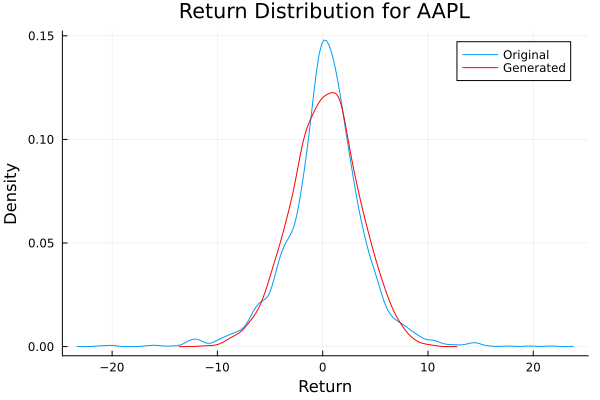

In [35]:
let

    # initialize -
    ticker_index = findfirst(==(ticker_to_compare), list_of_tickers); # find the index of the ticker we want to compare

    # let's plot the return distribution -
    density(G[:, ticker_index], label="Original", title="Return Distribution for $ticker_to_compare", xlabel="Return", ylabel="Density")
    density!(Ĝ[:, ticker_index], label="Generated", color=:red)
end

__Auto-correlation structure of the generated data__: Let's check if the generated data has a similar auto-correlation structure to the original data. We can compute the auto-correlation function for each ticker in both the original and generated datasets, and compare them.

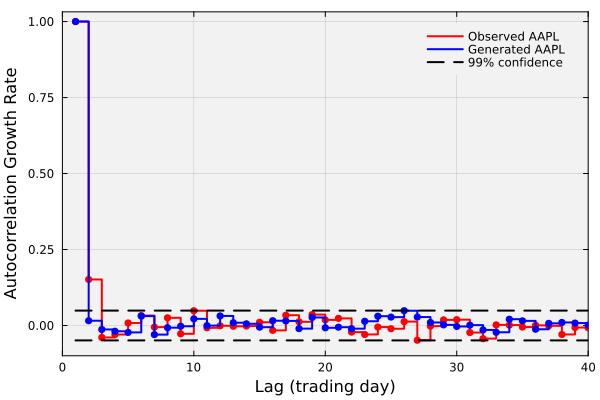

In [36]:
let

    # generate a random index -
    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    number_of_steps = maximum_number_trading_days - 1;
    max_number_of_steps_x = 40
    X = G[:,i]; # TODO: change to Ĝ to compare the generated data instead of the original data
    X̂ = Ĝ[:,i]; # this is the generated data for the same ticker
    
    # Observed autocorrelation for the original data
    plot(autocor(X, (0:(number_of_steps - 1) |> collect)), label="Observed $(ticker_to_compare)", lw=2, c=:red, 
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, 
        linetype=:steppost, xlims=(0,max_number_of_steps_x))
    scatter!(autocor(X, (0:(number_of_steps - 1) |> collect)), label="", c=:red, msc=:red)
    
    # Autocorrelation for the generated data
    plot!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="Generated $(ticker_to_compare)", lw=2, c=:blue, linetype=:steppost)
    scatter!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="", c=:blue, msc=:blue)
    
    # Confidence intervals for null hypothesis of no autocorrelation (dashed lines)
    LINE = (2.576/sqrt(number_of_steps))*ones(number_of_steps-1);
    plot!(LINE, label="99% confidence", lw=2, c=:black, ls=:dash)
    plot!(-LINE, label="", lw=2, c=:black, ls=:dash)
    xlabel!("Lag (trading day)", fontsize=18)
    ylabel!("Autocorrelation Growth Rate", fontsize=18)

    # uncomment me to save to file -
    # savefig(joinpath(_PATH_TO_FIGS, "Fig-Autocorrelation-HMM-GenModel-$(ticker_to_compare).pdf"));
end

### Volatility clustering
Next, let's consider volatility clustering. Volatility clustering is determined by examining the autocorrelation of the absolute values of the growth rate for different lag values. In actual data, we expect positive absolute autocorrelation for short lags. Volatility clustering indicates that periods of high volatility, such as significant changes in returns, tend to occur close together in time.

`Unhide` the code block below to see how we computed and plotted the [autocorrelation function](https://en.wikipedia.org/wiki/Autocorrelation) for the absolute values of the observed growth rates.

The observed dataset (red line) shows positive autocorrelation for lags less than approximately `10 days` at a 99% confidence level. This suggests the market (or individual ticker) has a memory of approximately 10 days or less following significant disruptions.

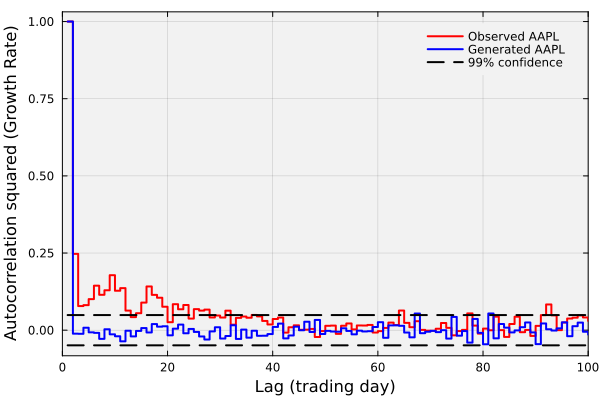

In [37]:
let

    # generate a random index -
    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    number_of_steps = maximum_number_trading_days - 1;
    max_number_of_steps_x = 100
    X = (G[:,i]).^2;
    X̂ = (Ĝ[:,i]).^2;

    plot(autocor(X, (0:(number_of_steps - 1) |> collect)), label="Observed $(ticker_to_compare)", lw=2, c=:red,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, linetype=:steppost,
    xlims=(0,max_number_of_steps_x))

    plot!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="Generated $(ticker_to_compare)", lw=2, c=:blue,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, linetype=:steppost,
    xlims=(0,max_number_of_steps_x))
    
    LINE = (2.576/sqrt(number_of_steps))*ones(number_of_steps-1);
    plot!(LINE, label="99% confidence", lw=2, c=:black, ls=:dash)
    plot!(-LINE, label="", lw=2, c=:black, ls=:dash)
    xlabel!("Lag (trading day)", fontsize=18)
    ylabel!("Autocorrelation squared (Growth Rate)", fontsize=18)

    
    # uncomment me to save to file -
    # savefig(joinpath(_PATH_TO_FIGS, "Fig-Autocorrelation-HMM-GenModel-$(ticker_to_compare).pdf"));
end

## Summary
One concise, direct summary sentence goes here.

> __Key Takeaways:__
>
> Three key learning objectives go here

One concise, direct summary concluding sentence goes here.
___